In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [53]:
news_df = pd.read_csv("data/processed_news_data.csv")  # Dataset with keyword counts
crimes_df = pd.read_csv("data/crimes_number.csv")  # Dataset with crime counts

# Convert dates to datetime format
news_df["Дата"] = pd.to_datetime(news_df["Дата"])
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], format="%Y-%m")

# Convert dates to 'YYYY-MM' format
news_df["Дата"] = news_df["Дата"].dt.to_period("M")
crimes_df["Date"] = crimes_df["Date"].dt.to_period("M")

# Merge datasets by the date column
df = pd.merge(news_df, crimes_df, left_on="Дата", right_on="Date", how="inner")

# Remove duplicate date column if necessary
df.drop(columns=["Дата"], inplace=True)

In [54]:
# Translate keywords to english
column_translation = {
    "коррупция": "corruption",
    "взятка": "bribe",
    "приговор": "verdict",
    "хищение": "embezzlement",
    "расследование": "investigation",
    "задержание": "detention",
    "доллар": "dollar",
    "миллион": "million",
    "миллиард": "billion",
    "агентство": "agency",
    "преступление": "crime",
    "суд": "court",
    "министерство": "ministry",
    "аким": "akim",
    "начальник": "chief",
    "заместитель": "deputy",
    "район": "district",
    "город": "city",
    "область": "region",
    "правонарушение": "offense",
}

df.rename(columns=column_translation, inplace=True)


In [55]:
df.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,...,ministry,akim,chief,deputy,district,city,region,offense,Date,Total Crimes
0,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,...,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,2016-11,3463.0
1,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,...,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,2016-12,3214.0
2,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,...,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,2017-01,1137.0
3,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,...,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,2017-02,1337.0
4,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,...,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,2017-03,1566.0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   corruption     99 non-null     int64    
 1   bribe          99 non-null     float64  
 2   verdict        99 non-null     float64  
 3   embezzlement   99 non-null     float64  
 4   investigation  99 non-null     float64  
 5   detention      99 non-null     float64  
 6   dollar         99 non-null     float64  
 7   million        99 non-null     float64  
 8   billion        99 non-null     float64  
 9   agency         99 non-null     float64  
 10  crime          99 non-null     float64  
 11  court          99 non-null     float64  
 12  ministry       99 non-null     float64  
 13  akim           99 non-null     float64  
 14  chief          99 non-null     float64  
 15  deputy         99 non-null     float64  
 16  district       99 non-null     float64  
 17  city           99 

In [57]:
df['Date'] = df['Date'].dt.to_timestamp('s').dt.strftime('%Y-%m-%d')
df["Date"] = pd.to_datetime(df["Date"])

In [58]:
df.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,...,ministry,akim,chief,deputy,district,city,region,offense,Date,Total Crimes
0,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,...,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,2016-11-01,3463.0
1,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,...,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,2016-12-01,3214.0
2,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,...,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,2017-01-01,1137.0
3,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,...,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,2017-02-01,1337.0
4,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,...,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,2017-03-01,1566.0


Correlation with the target variable:
Total Crimes     1.000000
dollar           0.265334
corruption       0.194084
crime            0.191749
bribe            0.174378
investigation    0.172849
agency           0.151473
ministry         0.148085
region           0.132093
detention        0.123826
district         0.121275
city             0.108854
million          0.108031
akim             0.101624
deputy           0.094644
verdict          0.077149
chief            0.045715
court            0.032344
offense          0.031368
embezzlement     0.013643
billion         -0.084033
Date            -0.413425
Name: Total Crimes, dtype: float64


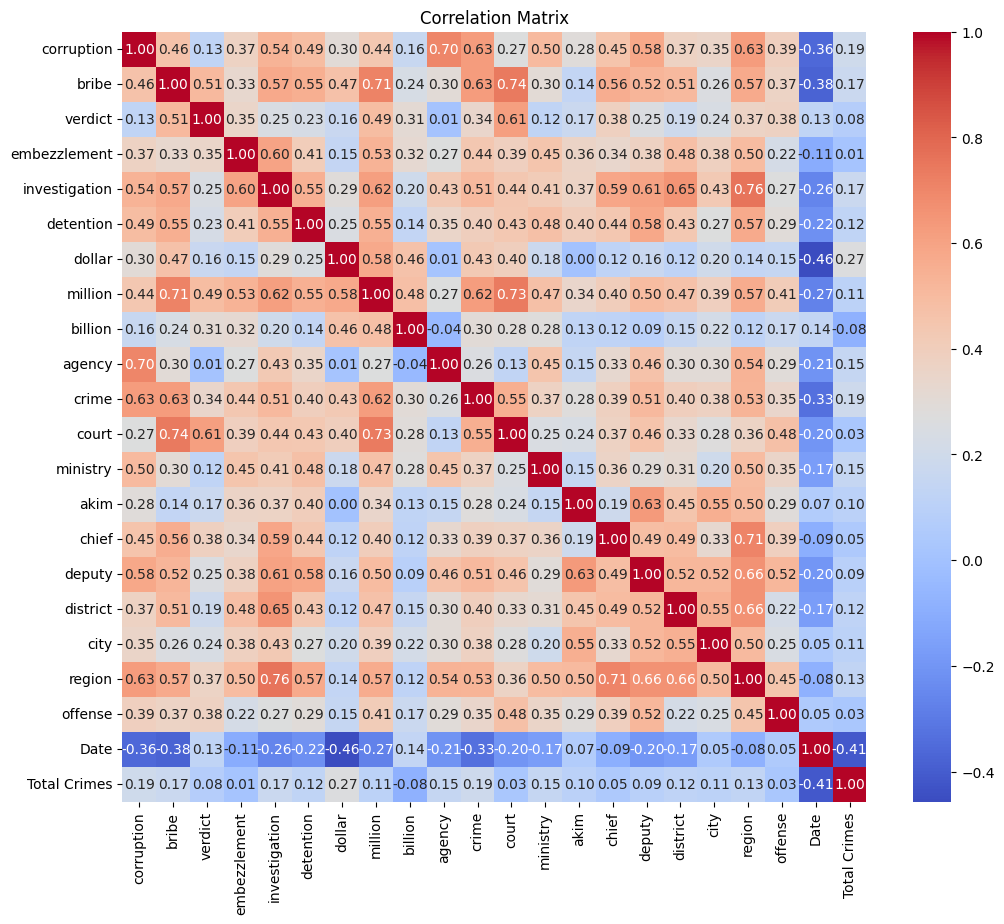

In [59]:
# Calculate correlation
correlation_matrix = df.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [60]:
# Create a new dataframe with aggregated features
df_agg = pd.DataFrame()

# Aggregated features
df_agg['Corruption_Sum'] = df[['corruption', 'bribe', 'verdict', 'embezzlement', 'investigation']].sum(axis=1)
df_agg['Detentions_Sum'] = df[['detention']].sum(axis=1)
df_agg['Finance_Sum'] = df[['dollar', 'million', 'billion']].sum(axis=1)
df_agg['Authorities_Sum'] = df[['agency', 'ministry', 'akim', 'chief', 'deputy', 'district', 'city', 'region']].sum(axis=1)
df_agg['Offenses_Sum'] = df[['crime', 'offense', 'court']].sum(axis=1)

# Add time components
df_agg['Month'] = pd.to_datetime(df['Date']).dt.month
df_agg['Year'] = pd.to_datetime(df['Date']).dt.year

# Target variable
df_agg['Total Corruption Crimes'] = df['Total Crimes']

df_agg


,Corruption_Sum,Detentions_Sum,Finance_Sum,Authorities_Sum,Offenses_Sum,Month,Year,Total Corruption Crimes
0,161.0,20.0,57.0,125.0,56.0,11,2016,3463.0
1,81.0,7.0,19.0,76.0,28.0,12,2016,3214.0
2,86.0,16.0,24.0,75.0,32.0,1,2017,1137.0
3,90.0,10.0,69.0,50.0,56.0,2,2017,1337.0
4,119.0,8.0,65.0,117.0,99.0,3,2017,1566.0
...,...,...,...,...,...,...,...,...
94,64.0,13.0,35.0,98.0,42.0,9,2024,1903.0
95,61.0,1.0,61.0,79.0,22.0,10,2024,1989.0
96,77.0,5.0,36.0,73.0,52.0,11,2024,2100.0
97,64.0,7.0,39.0,62.0,40.0,12,2024,2098.0


Correlation with the target variable:
Total Corruption Crimes    1.000000
Month                      0.848798
Corruption_Sum             0.200789
Authorities_Sum            0.161576
Detentions_Sum             0.123826
Finance_Sum                0.120446
Offenses_Sum               0.075755
Year                      -0.516458
Name: Total Corruption Crimes, dtype: float64


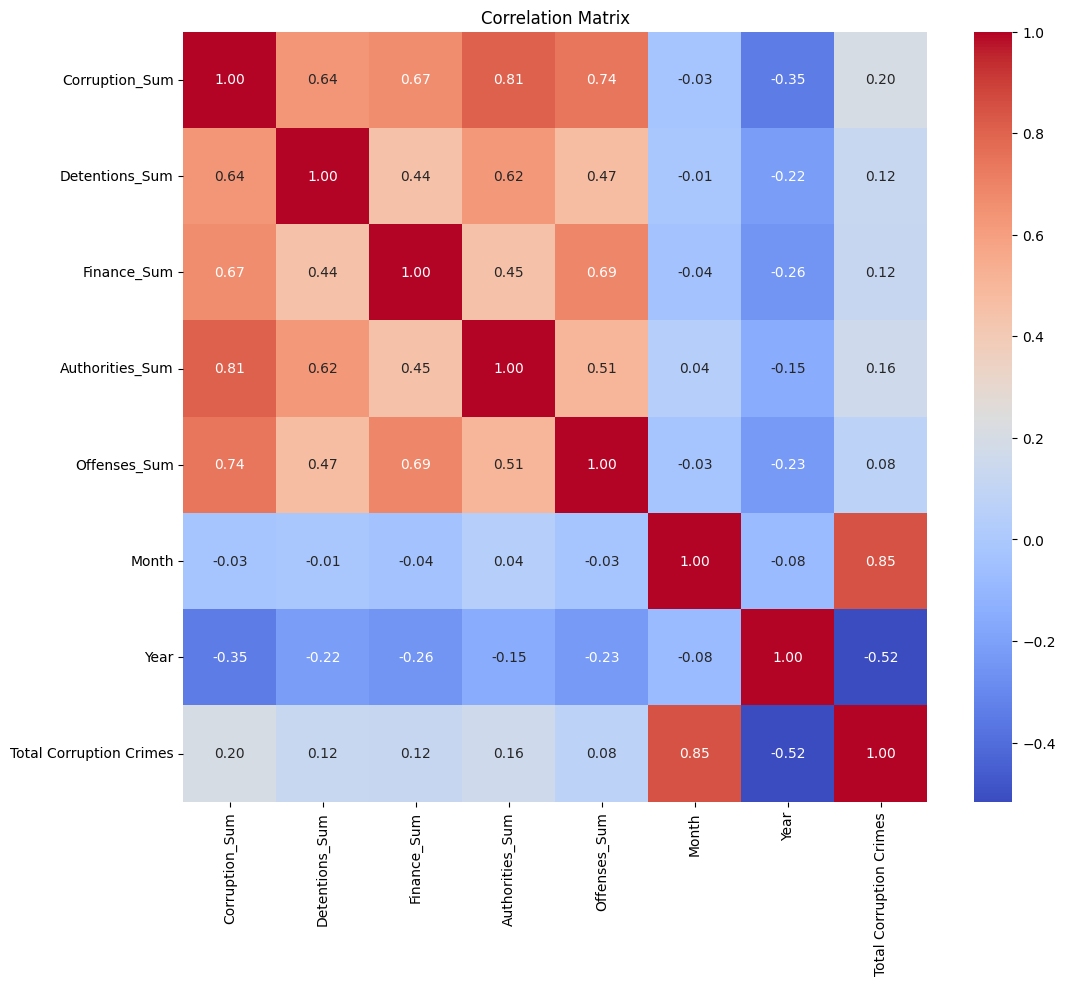

In [61]:
# Calculate correlation
correlation_matrix = df_agg.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Corruption Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [62]:
df_agg_new = df_agg[['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum', 'Offenses_Sum']].sum(axis=1)
df_agg_new = df_agg_new.to_frame(name="Total_Keywords")  # Преобразуем в DataFrame с названием столбца
df_agg_new = pd.concat([df_agg[["Month", "Year", "Total Corruption Crimes"]], df_agg_new], axis=1)  # Объединяем


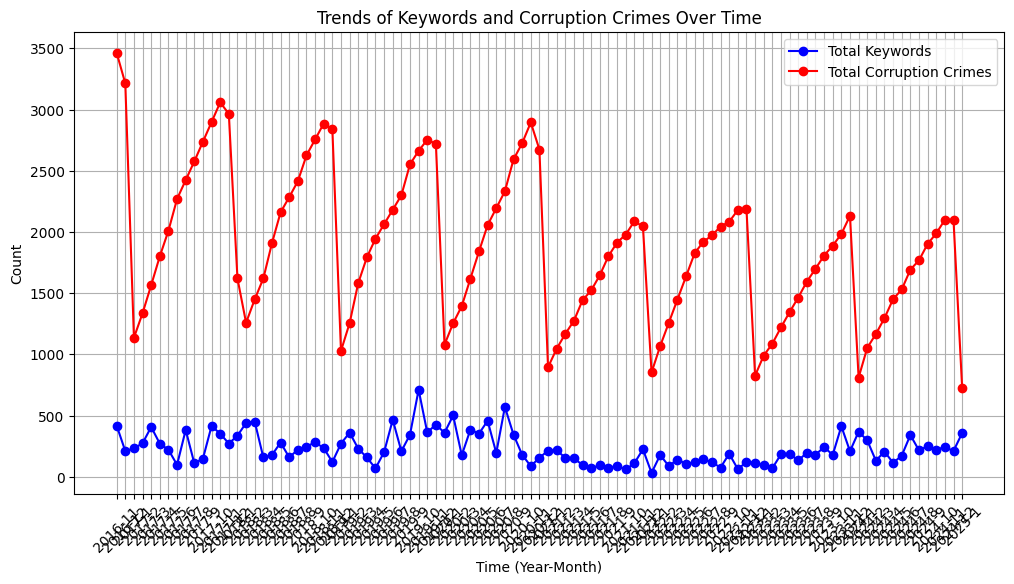

In [63]:
plt.figure(figsize=(12, 6))

# Строим график количества ключевых слов
plt.plot(df_agg_new["Year"].astype(str) + "-" + df_agg_new["Month"].astype(str), 
         df_agg_new["Total_Keywords"], 
         label="Total Keywords", color="blue", marker="o")

# Строим график количества преступлений
plt.plot(df_agg_new["Year"].astype(str) + "-" + df_agg_new["Month"].astype(str), 
         df_agg_new["Total Corruption Crimes"], 
         label="Total Corruption Crimes", color="red", marker="o")

# Улучшаем вид
plt.xticks(rotation=45)  # Поворачиваем подписи на оси X
plt.xlabel("Time (Year-Month)")
plt.ylabel("Count")
plt.title("Trends of Keywords and Corruption Crimes Over Time")
plt.legend()
plt.grid()

plt.show()

In [64]:
from scipy.stats import pearsonr

# Рассчитываем коэффициент корреляции Пирсона
corr, p_value = pearsonr(df_agg_new["Total_Keywords"], df_agg_new["Total Corruption Crimes"])

print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.3f}")


Pearson correlation: 0.172, p-value: 0.088


In [65]:
from statsmodels.tsa.stattools import grangercausalitytests

# Подготовка данных (нужен временной лаг, например, 1 месяц)
data = df_agg_new[["Total Corruption Crimes", "Total_Keywords"]].dropna()

# Тест Гранджера с лагом 1
test_result = grangercausalitytests(data, maxlag=1, verbose=True)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.8952  , p=0.1718  , df_denom=95, df_num=1
ssr based chi2 test:   chi2=1.9551  , p=0.1620  , df=1
likelihood ratio test: chi2=1.9358  , p=0.1641  , df=1
parameter F test:         F=1.8952  , p=0.1718  , df_denom=95, df_num=1


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [66]:
# Splitting the original dataset into features (X) and target variable (y)
X_df = df.drop(columns=["Total Crimes", "Date"])
y_df = df["Total Crimes"]
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.2, random_state=13)

# Splitting the aggregated dataset into features (X) and target variable (y)
X_agg = df_agg.drop(columns=["Total Corruption Crimes"])
y_agg = df_agg["Total Corruption Crimes"]
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y_agg, test_size=0.2, random_state=13)

In [67]:
# Function for training and evaluating a model
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}")
    print("-" * 30)

In [68]:
# List of models
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=13)),
    ("Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=100, random_state=13)),
    ("XGBoost Regressor", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=13))
]

In [69]:
# Training and evaluation for df
print("Model evaluation on df:")
for name, model in models:
    evaluate_model(model, X_train_df, X_test_df, y_train_df, y_test_df, name)

# Training and evaluation for df_agg
print("Model evaluation on df_agg:")
for name, model in models:
    evaluate_model(model, X_train_agg, X_test_agg, y_train_agg, y_test_agg, name)

Model evaluation on df:
Linear Regression:
MAE: 554.20, MSE: 586670.13, R2: -0.47
------------------------------
Ridge Regression:
MAE: 553.98, MSE: 586135.83, R2: -0.47
------------------------------
Lasso Regression:
MAE: 554.17, MSE: 586606.47, R2: -0.47
------------------------------
ElasticNet:
MAE: 553.32, MSE: 584546.31, R2: -0.47
------------------------------
Random Forest Regressor:
MAE: 474.45, MSE: 379755.30, R2: 0.05
------------------------------
Gradient Boosting Regressor:
MAE: 541.85, MSE: 475861.61, R2: -0.19
------------------------------
XGBoost Regressor:
MAE: 530.06, MSE: 462366.49, R2: -0.16
------------------------------
Model evaluation on df_agg:
Linear Regression:
MAE: 150.74, MSE: 34387.88, R2: 0.91
------------------------------
Ridge Regression:
MAE: 150.65, MSE: 34342.42, R2: 0.91
------------------------------
Lasso Regression:
MAE: 150.73, MSE: 34381.47, R2: 0.91
------------------------------
ElasticNet:
MAE: 150.37, MSE: 34215.40, R2: 0.91
-----------

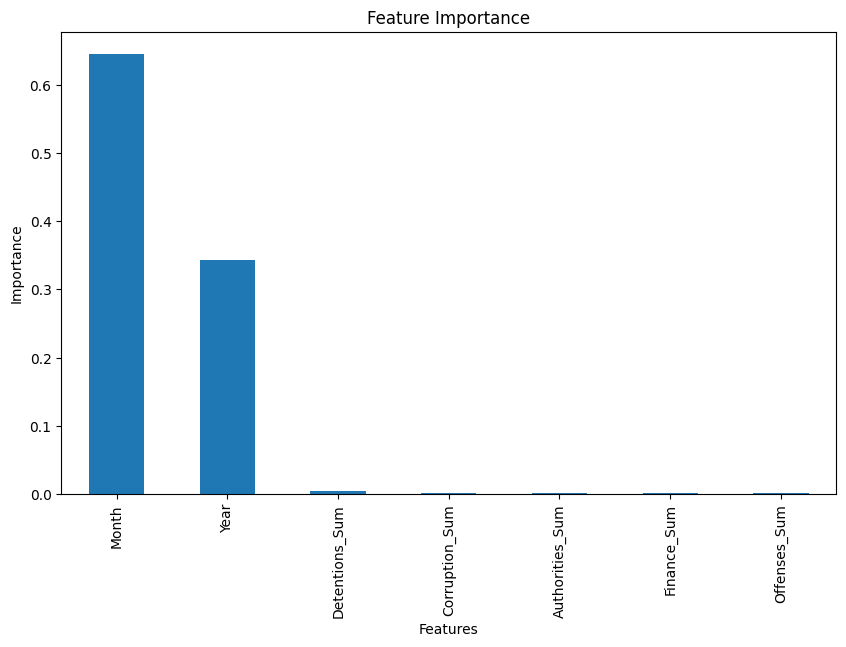

In [70]:
# Обучение модели XGBoost на агрегированных данных
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb_model.fit(X_train_agg, y_train_agg)

# Вычисление важности признаков
importance = pd.Series(xgb_model.feature_importances_, index=X_agg.columns)

# Сортировка и визуализация
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 6), title="Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Year and month are the highest correlation with total crimes number. Thus, we use Time Series Analysis

In [71]:
df_agg.columns

Index(['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum',
       'Offenses_Sum', 'Month', 'Year', 'Total Corruption Crimes'],
      dtype='object')

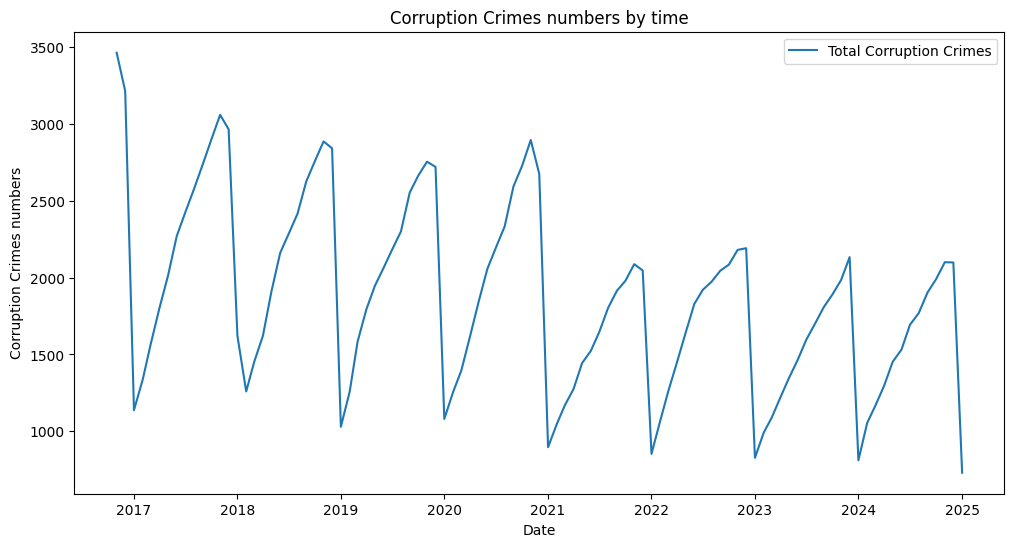

In [72]:
# Убедимся, что 'Дата' является индексом
df_agg['Date'] = pd.to_datetime(df_agg['Year'].astype(str) + '-' + df_agg['Month'].astype(str))
df_agg.set_index('Date', inplace=True)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df_agg.index, df_agg['Total Corruption Crimes'], label="Total Corruption Crimes")
plt.title("Corruption Crimes numbers by time")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes numbers")
plt.legend()
plt.show()

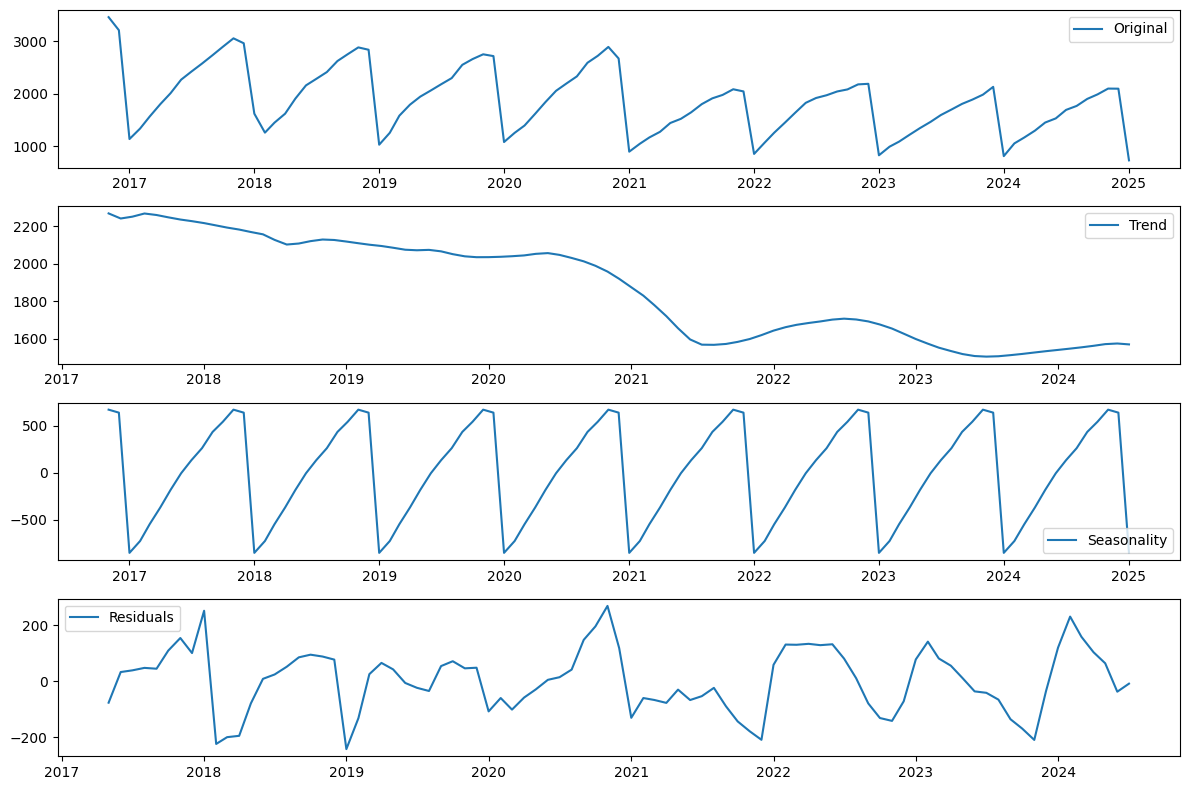

In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition of the time series
decomposition = seasonal_decompose(df_agg['Total Corruption Crimes'], model='additive', period=12)

# Visualization of components
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_agg['Total Corruption Crimes'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


Original (исходный временной ряд)

Наблюдается четко выраженная сезонность (ежегодные колебания).
В целом есть нисходящий тренд с 2017 по 2021, затем стабилизация.
Резкие падения в конце каждого года, возможно, связаны с отчетными периодами или административными циклами.
Trend (трендовая составляющая)

Видно, что общее число коррупционных преступлений снижалось примерно с 2018 по 2021 год, а затем вышло на плато.
Это может быть связано с изменением политики, законодательства или общественного внимания к коррупции.
После 2021 года ситуация стабилизировалась, но явного роста нет.
Seasonality (сезонность)

Очень стабильный годовой цикл: сначала резкий рост, затем спад.
Сезонность явно повторяется из года в год без значительных изменений.
Это говорит о том, что преступления, скорее всего, связаны с регулярными событиями (например, отчетными периодами, изменениями финансирования, антикоррупционными кампаниями).
Residuals (остатки)

Остатки не выглядят случайными, что говорит о наличии еще неучтенных факторов.
В идеале, если модель адекватно описывает данные, остатки должны быть случайным шумом без видимой структуры.
Здесь же мы видим некоторые закономерности, что указывает на возможные нелинейные зависимости или влияние внешних факторов (экономики, политики, реформ).

1. Общий обзор политических событий в анализируемый период
Март 2019 года: Передача власти от Нурсултана Назарбаева к Касым-Жомарту Токаеву.

Возможные последствия:
Перестановки в правительстве и акиматах.
Запуск новых антикоррупционных инициатив или, наоборот, «пауза» в старых программах.
Июнь 2019 года: Внеочередные президентские выборы.

Возможные последствия:
Перед выборами обычно активизируются расследования, либо наоборот снижается «публичность» дел.
Усиление либо ослабление роли антикоррупционных органов в этот период.
2020 год (март-май): Начало пандемии COVID-19, локдауны, кризис в экономике.

Возможные последствия:
Перераспределение бюджетов, рост госзакупок (медицина, инфраструктура).
Увеличение риска коррупции при экстренных закупках.
Возможное снижение фактических регистраций преступлений из-за удаленной работы органов и сокращения проверок.
2021 год:

Внедрение некоторых реформ, кадровые перестановки в акиматах и министерствах.
Возможные последствия:
Новые антикоррупционные инициативы (расширение полномочий Антикора).
Принятие поправок в законодательство, влияющих на квалификацию коррупционных преступлений.
Январь 2022 года (Трагические события в Казахстане):

Политический кризис и протесты в ряде регионов.
Возможные последствия:
Могли временно повлиять на работу правоохранительных органов.
Возможен всплеск «скрытых» коррупционных схем на фоне общей нестабильности.
2022–2023 годы:

Дальнейшие реформы в системе госуправления.
Усиление роли Антикора и ужесточение наказаний за коррупцию.

2. Сопоставление динамики преступлений с событиями
2017–2018 годы:

Тренд показывает постепенное снижение числа зарегистрированных преступлений.
Политически это время относительной стабильности при прежнем Президенте (Назарбаев).
Возможная гипотеза: антикоррупционные кампании могли замедлиться, а статистика могла «зачищаться» или же экономические факторы способствовали снижению «возможностей» для хищений.
2019 год (передача власти, выборы):

По графикам сезонной декомпозиции обычно наблюдается ежегодный «пик» в начале года и спад к концу.
Если в 2019 году мы видим аномальный скачок/спад, можно связать это с:
Усилением антикоррупционной риторики во время выборов.
Кампаниями по «показательной» борьбе с коррупцией для демонстрации нового курса.
2020 год (пандемия):

Если графики показывают нестандартные колебания в 2020 году, это может указывать на:
Рост коррупции при госзакупках (СИЗ, аппаратура).
Снижение фактических расследований из-за удаленной работы и перераспределения сил на борьбу с COVID-19.
2021 год (стабилизация или новые реформы):

Если тренд выровнялся, это может говорить о том, что система пришла в «новое равновесие» после потрясений 2020-го.
Запуск реформ в правоохранительной системе мог повысить «прозрачность» или, наоборот, частично скрыть реальные данные.
Январь 2022 года и далее:

Если в начале 2022 года мы видим аномалии (рост или спад), возможно, это следствие «шокового» периода.
Последующая политика Токаева (например, публичные заявления о «новом Казахстане») могла усилить фокус на антикоррупционных делах или повлиять на методы учета.

3. Ключевые выводы и гипотезы
Отсутствие корреляции с количеством новостей:

Если данные показывают, что преступления не растут вместе с упоминаниями в СМИ, можно предположить, что СМИ не напрямую влияют на регистрацию дел, а статистика преступлений может «контролироваться» (занижаться или «корректироваться»).
Сильная сезонность:

Каждый год пик в начале (или в конце) может совпадать с бюджетными циклами, отчетными периодами, либо традиционными «кампаниями» правоохранительных органов (например, перед праздниками, перед выборами).
Влияние политических событий:

Перестановки в правительстве, выборы, реформы могут приводить к всплескам или спадам в регистрациях.
Анализ временных рядов с метками «политических событий» может показать, что вблизи ключевых дат (месяц до или месяц после) наблюдаются выбросы.
Возможные скрытые факторы:

Макроэкономика (кризис, инфляция, сокращение бюджета) может приводить к росту или сокращению «возможностей» для хищений.
Региональные различия: если политические события носили локальный характер (например, массовые протесты в конкретном регионе), статистика может сильно отличаться от среднего по стране.

4. Рекомендации по дальнейшему анализу
Добавить «событийную разметку»

Создать бинарные (0/1) признаки для каждого важного события (например, «период выборов», «кадровые перестановки», «кризис COVID-19»).
Проверить, увеличивается ли вероятность всплеска преступлений в эти периоды (логистическая регрессия или модель временных рядов с dummy-переменными).
Использовать SARIMA/XGBoost/Prophet

SARIMA учитывает сезонность; можно добавить экзогенные переменные (политические события) как exog.
XGBoost на временных рядах (с генерацией лагов и dummy-признаков событий) также может показать хорошие результаты.
Сравнить статистику регионов

Если есть данные по областям, акиматам, можно изучить, какие области показывают всплески в периоды смены акима или больших проектов.
Проверить стационарность

Провести ADF-тест, KPSS-тест, чтобы убедиться, что ряды стационарны или корректно дифференцированы, прежде чем делать выводы о трендах.
Итог
Политические события в Казахстане, такие как выборы, перестановки в правительстве и кризисные моменты (COVID-19, январские события 2022 года), вполне могут влиять на динамику коррупционных преступлений, отражаясь в отчетах либо искажаясь.
Графики сезонной декомпозиции демонстрируют четкий повторяющийся паттерн, который может совпадать с ежегодными бюджетными или административными циклами.
Для более точного вывода рекомендуется добавить в модель временных рядов бинарные признаки событий и экзогенные экономические/политические факторы, чтобы количественно оценить их влияние.

## Time Series Analysis with ARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


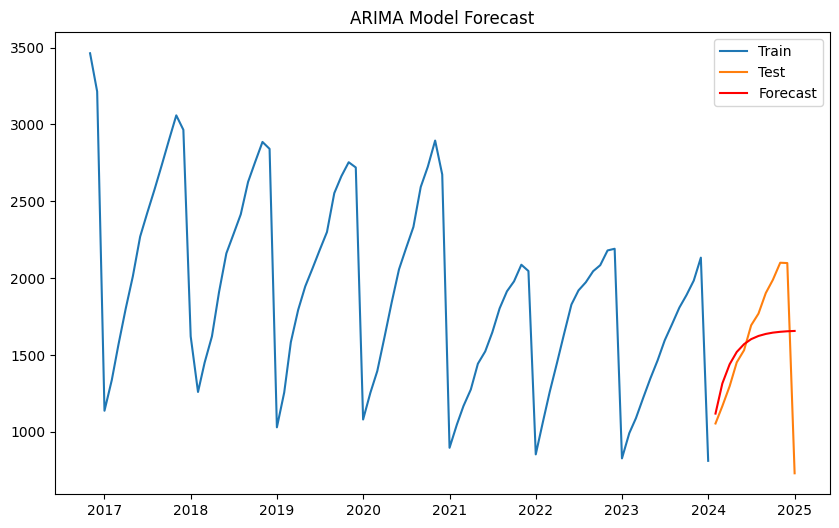

Mean Squared Error: 127302.91


In [74]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


# Set index to Month
# df_agg.index = pd.to_datetime(df_agg.index).to_period('M')

# Divide the data into training and test data
train = df_agg['Total Corruption Crimes'][:-12]
test = df_agg['Total Corruption Crimes'][-12:]

# Building the ARIMA model
model = ARIMA(train, order=(1, 1, 1))  # ARIMA(p, d, q) parameters
model_fit = model.fit()

# Forecasting
forecast = model_fit.forecast(steps=12)
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.title("ARIMA Model Forecast")
plt.legend()
plt.show()

# MSE
mse = mean_squared_error(test, forecast)
print(f"Mean Squared Error: {mse:.2f}")


Что в целом можно сказать по графику?

Временной ряд явно сезонный (есть повторяющиеся колебания).
Модель ARIMA (1,1,1) плохо передает сезонность, так как прогноз (оранжевая линия) сглаженный.
Настоящие данные имеют более резкие спады и подъемы, а модель делает более мягкий прогноз.
Можно попробовать SARIMA (учитывает сезонность) или Prophet для более точного предсказания.

## Time Series Analysis with SARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\asanb\AppData\Local\Temp\ipykernel_16792\384774507.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1),


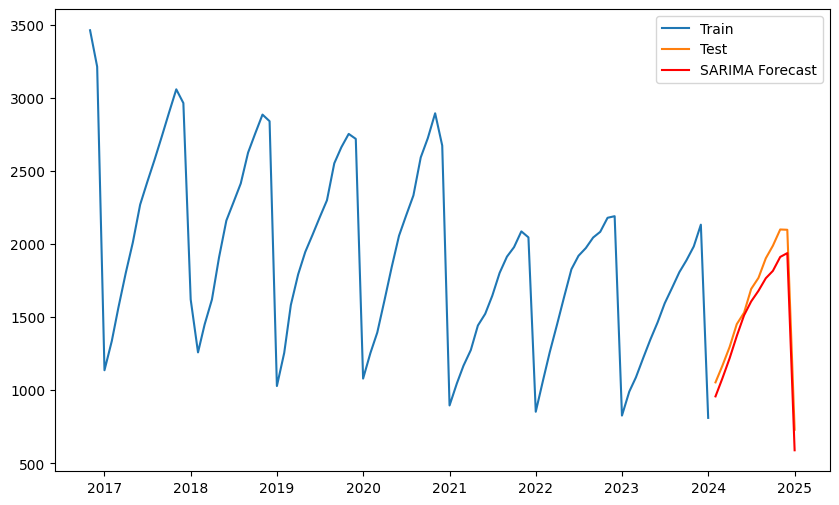

SARIMA Metrics:
MAE: 110.74
MSE: 14450.95
R2: 0.92

         Дата  SARIMA Forecast
0  2024-01-31       958.082321
1  2024-02-29      1080.736042
2  2024-03-31      1219.920264
3  2024-04-30      1370.711688
4  2024-05-31      1513.083165
5  2024-06-30      1607.721513
6  2024-07-31      1680.665822
7  2024-08-31      1766.455586
8  2024-09-30      1816.879387
9  2024-10-31      1912.148114
10 2024-11-30      1938.379817
11 2024-12-31       589.331929


In [90]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA: set period=12
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()
forecast_sarima = model_fit_sarima.forecast(steps=12)

# Create forecast df
df_sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1), 
                                                     periods=12, freq='M'),
                                'SARIMA Forecast': forecast_sarima.values})

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_sarima, label="SARIMA Forecast", color='red')
plt.legend()
plt.show()

# Metrics
mae = mean_absolute_error(test, forecast_sarima)
mse = mean_squared_error(test, forecast_sarima)
r2 = r2_score(test, forecast_sarima)

print(f"SARIMA Metrics:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR2: {r2:.2f}")
print(f"\n{df_sarima_forecast}")

### Forecasting corruption crimes numbers for the next two years with SARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\asanb\AppData\Local\Temp\ipykernel_16792\542263269.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]


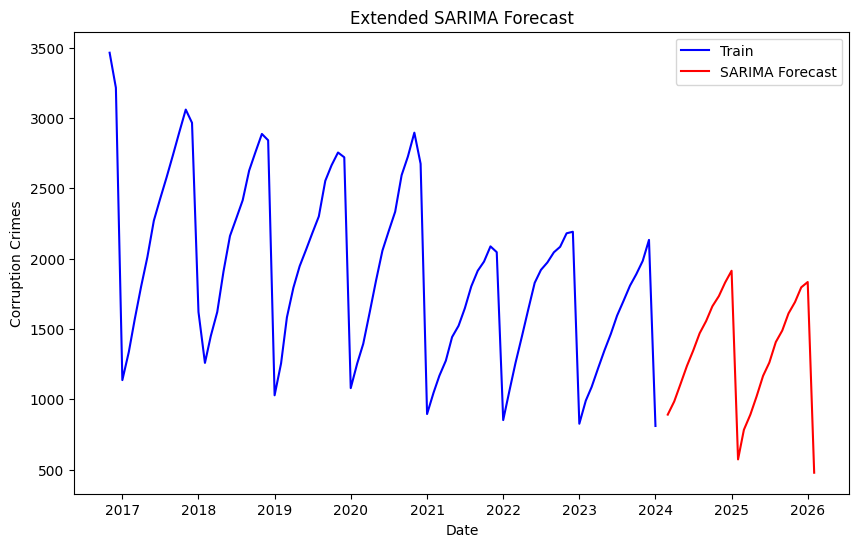

                 Date  SARIMA Forecast
2025-02-01 2024-02-29       891.593610
2025-03-01 2024-03-31       985.271913
2025-04-01 2024-04-30      1108.551810
2025-05-01 2024-05-31      1237.972298
2025-06-01 2024-06-30      1346.678524
2025-07-01 2024-07-31      1469.984311
2025-08-01 2024-08-31      1556.473238
2025-09-01 2024-09-30      1661.546837
2025-10-01 2024-10-31      1733.568416
2025-11-01 2024-11-30      1829.951580
2025-12-01 2024-12-31      1913.843331
2026-01-01 2025-01-31       573.517742
2026-02-01 2025-02-28       783.833745
2026-03-01 2025-03-31       891.636289
2026-04-01 2025-04-30      1021.456375
2026-05-01 2025-05-31      1167.039338
2026-06-01 2025-06-30      1261.470603
2026-07-01 2025-07-31      1407.194556
2026-08-01 2025-08-31      1489.147527
2026-09-01 2025-09-30      1610.809275
2026-10-01 2025-10-31      1691.129607
2026-11-01 2025-11-30      1796.008153
2026-12-01 2025-12-31      1833.805564
2027-01-01 2026-01-31       478.842831


In [91]:
# Fit the SARIMA model
model_sarima = SARIMAX(df_agg['Total Corruption Crimes'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

# Generate forecasts for the entire range, including 2025
forecast_steps = 24  # Adjust this to include 2025 (e.g., 24 months = 2 years from the end of training data)
sarima_forecast = model_fit_sarima.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]
sarima_forecast_values = sarima_forecast.predicted_mean

# Create a DataFrame for the SARIMA forecast
sarima_forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'SARIMA Forecast': sarima_forecast_values
})

# Plot the extended forecast
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train", color="blue")
plt.plot(sarima_forecast_df['Date'], sarima_forecast_df['SARIMA Forecast'], label="SARIMA Forecast", color="red")
plt.title("Extended SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes")
plt.legend()
plt.show()

# Print the extended SARIMA forecast
print(sarima_forecast_df)

## Time Series Analysis with Prophet

16:52:36 - cmdstanpy - INFO - Chain [1] start processing
16:52:36 - cmdstanpy - INFO - Chain [1] done processing


            ds         yhat
111 2026-01-31   823.154192
112 2026-02-28   552.358453
113 2026-03-31   788.175999
114 2026-04-30  1022.873586
115 2026-05-31  1277.057334
116 2026-06-30  1447.894897
117 2026-07-31  1595.410836
118 2026-08-31  1767.515382
119 2026-09-30  1806.652371
120 2026-10-31  1635.122934
121 2026-11-30  1839.983854
122 2026-12-31   503.232846


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


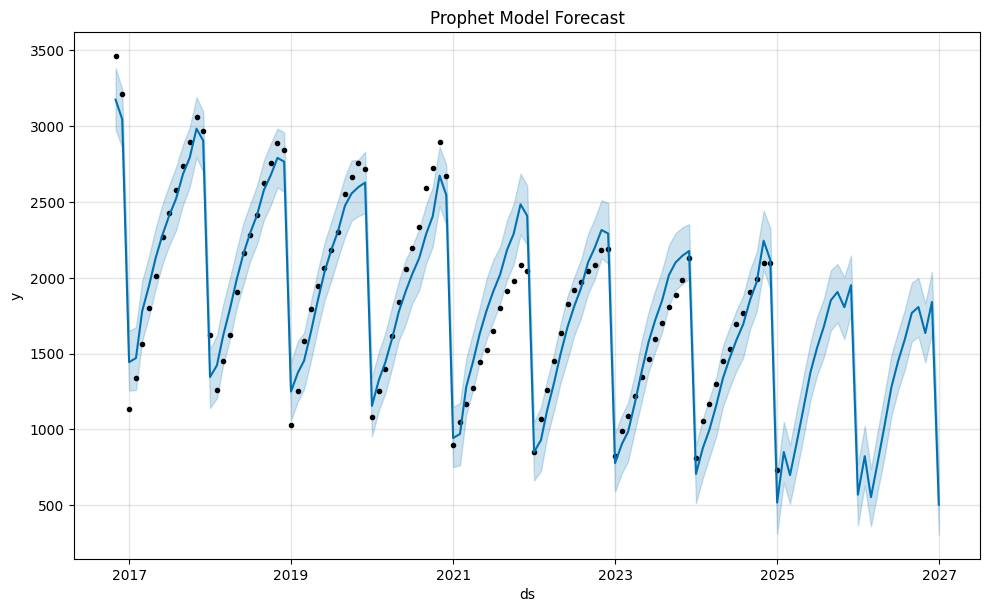

Prophet Metrics:
MAE: 107.55
MSE: 15350.48
R2: 0.91


In [ ]:
from prophet import Prophet

# Preparing data for Prophet
prophet_df = df_agg.reset_index()[['Date', 'Total Corruption Crimes']]
prophet_df.columns = ['ds', 'y']  # Prophet's requirements

# Prophet model fit
model = Prophet()
model.fit(prophet_df)

# Forecast
future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)

# Prophet прогноз на 12 месяцев вперёд
prophet_forecast = forecast[['ds', 'yhat']].iloc[-12:]
print(prophet_forecast)

# Plot
fig = model.plot(forecast)
plt.title("Prophet Model Forecast")
plt.show()

# Extracting the real test values (last 12 months)
test = prophet_df.iloc[-12:]
test = test.set_index('ds')

# Extracting the predicted values for the test period
forecast_test = forecast[['ds', 'yhat']].set_index('ds').loc[test.index]

# Metrics
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
mse = mean_squared_error(test['y'], forecast_test['yhat'])
r2 = r2_score(test['y'], forecast_test['yhat'])

# Results
print(f"Prophet Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

